In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

# Read data

In [3]:
vanilla = pd.read_csv('adult-mpa-bin-wout-agg-vanilla_lr-100.csv', index_col=0)
zhang = pd.read_csv('adult-mpa-bin-wout-agg-mult_adv-100.csv', index_col=0)

In [4]:
vanilla

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FP_g0,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.8417,0.8417,0.7685,0.8183,0.8840,0.8454,5711.0000,611.0000,...,623.0000,1313.0000,1743.0000,1559.0000,63.0000,149.0000,153.0000,0.7814,0.8376,0.7620
1,SkVanillaLR,29,0.8405,0.8405,0.7680,0.8151,0.8810,0.8410,5682.0000,627.0000,...,646.0000,1290.0000,1764.0000,1556.0000,60.0000,168.0000,145.0000,0.7764,0.8501,0.7927
2,SkVanillaLR,42,0.8443,0.8443,0.7775,0.8023,0.8806,0.8482,5580.0000,671.0000,...,677.0000,1212.0000,1861.0000,1518.0000,74.0000,150.0000,151.0000,0.7668,0.8560,0.8075
3,SkVanillaLR,55,0.8381,0.8381,0.7629,0.8275,0.8956,0.8587,5722.0000,564.0000,...,589.0000,1375.0000,1720.0000,1514.0000,61.0000,172.0000,145.0000,0.7878,0.8467,0.7775
4,SkVanillaLR,73,0.8369,0.8369,0.7668,0.8093,0.8915,0.8657,5599.0000,658.0000,...,689.0000,1309.0000,1826.0000,1586.0000,56.0000,159.0000,133.0000,0.7574,0.8387,0.7790


In [5]:
zhang

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod,last_cosine_similarity
0,MultAdvBin4DP,13,0.8370,0.8370,0.7748,0.7987,0.8988,0.9003,5450.0000,839.0000,...,1089.0000,1955.0000,1571.0000,42.0000,154.0000,148.0000,0.7214,0.7649,0.6695,0.2080
1,MultAdvBin4DP,29,0.8311,0.8311,0.7680,0.7868,0.8744,0.8603,5378.0000,900.0000,...,1060.0000,1976.0000,1574.0000,36.0000,197.0000,115.0000,0.7084,0.7486,0.6475,0.1435
2,MultAdvBin4DP,42,0.8331,0.8331,0.7753,0.7753,0.8840,0.8893,5255.0000,964.0000,...,980.0000,2080.0000,1539.0000,47.0000,178.0000,122.0000,0.7011,0.7892,0.7026,0.2747
3,MultAdvBin4DP,55,0.8326,0.8326,0.7696,0.8008,0.8940,0.8839,5440.0000,821.0000,...,1112.0000,1966.0000,1510.0000,57.0000,191.0000,125.0000,0.7253,0.7617,0.6570,0.3446
4,MultAdvBin4DP,73,0.8339,0.8339,0.7737,0.7917,0.8934,0.8862,5383.0000,840.0000,...,1080.0000,2041.0000,1597.0000,37.0000,185.0000,106.0000,0.7059,0.7741,0.6897,0.4692
5,MultAdvBin4EqOdds,13,0.8371,0.8371,0.7750,0.7987,0.9005,0.9042,5448.0000,841.0000,...,1087.0000,1957.0000,1571.0000,42.0000,154.0000,148.0000,0.7222,0.7722,0.6845,0.2110
6,MultAdvBin4EqOdds,29,0.8316,0.8316,0.7686,0.7876,0.8750,0.8603,5385.0000,893.0000,...,1064.0000,1972.0000,1568.0000,42.0000,193.0000,119.0000,0.7116,0.7510,0.6491,0.1443
7,MultAdvBin4EqOdds,42,0.8334,0.8334,0.7755,0.7791,0.8896,0.8974,5267.0000,952.0000,...,979.0000,2081.0000,1538.0000,48.0000,182.0000,118.0000,0.7051,0.7816,0.6866,0.2711
8,MultAdvBin4EqOdds,55,0.8323,0.8323,0.7690,0.8015,0.8953,0.8863,5442.0000,819.0000,...,1121.0000,1957.0000,1507.0000,60.0000,189.0000,127.0000,0.7292,0.7713,0.6741,0.3447
9,MultAdvBin4EqOdds,73,0.8346,0.8346,0.7748,0.7904,0.8918,0.8835,5383.0000,840.0000,...,1077.0000,2044.0000,1597.0000,37.0000,180.0000,111.0000,0.7066,0.7834,0.7083,0.4719


In [6]:
zhang[["model_name", "cv_seed", "last_cosine_similarity"]]

,model_name,cv_seed,last_cosine_similarity
0,MultAdvBin4DP,13,0.2080
1,MultAdvBin4DP,29,0.1435
2,MultAdvBin4DP,42,0.2747
3,MultAdvBin4DP,55,0.3446
4,MultAdvBin4DP,73,0.4692
5,MultAdvBin4EqOdds,13,0.2110
6,MultAdvBin4EqOdds,29,0.1443
7,MultAdvBin4EqOdds,42,0.2711
8,MultAdvBin4EqOdds,55,0.3447
9,MultAdvBin4EqOdds,73,0.4719


# Predictive performance

## Acc mean and std

In [6]:
vanilla_acc = vanilla.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([vanilla_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0029
1,MultAdvBin4DP,0.8335,0.0022
2,MultAdvBin4EqOdds,0.8338,0.0022
3,MultAdvBin4EqOpp,0.8311,0.0010


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['SkVanillaLR', 'MultAdvBin4DP', 'MultAdvBin4EqOdds', 'MultAdvBin4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0029
1,MultAdvBin4DP,0.8335,0.0022
2,MultAdvBin4EqOdds,0.8338,0.0022
3,MultAdvBin4EqOpp,0.8311,0.0010


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

0.8403 $\pm$ 0.0029
0.8335 $\pm$ 0.0022
0.8338 $\pm$ 0.0022
 0.8311 $\pm$ 0.001


## Micro-f1 mean and std

In [11]:
vanilla_micro = vanilla.groupby(['model_name'])['f1-micro'].agg([mean, stdev])
zhang_micro = zhang.groupby(['model_name'])['f1-micro'].agg([mean, stdev])

In [12]:
micro = pd.concat([vanilla_micro, zhang_micro])
micro = micro.reset_index()
micro = micro.rename(columns={'index': 'model_name'})
micro

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0029
1,MultAdvBin4DP,0.8335,0.0022
2,MultAdvBin4EqOdds,0.8338,0.0022
3,MultAdvBin4EqOpp,0.8311,0.0010


In [13]:
micro['model_name'] = names
micro

,model_name,mean,stdev
0,SkVanillaLR,0.8403,0.0029
1,MultAdvBin4DP,0.8335,0.0022
2,MultAdvBin4EqOdds,0.8338,0.0022
3,MultAdvBin4EqOpp,0.8311,0.0010


In [14]:
print((micro['mean'].round(4).astype(str) + ' $\pm$ ' + micro['stdev'].round(4).astype(str)).to_string(index=False))

0.8403 $\pm$ 0.0029
0.8335 $\pm$ 0.0022
0.8338 $\pm$ 0.0022
 0.8311 $\pm$ 0.001


## Macro-f1 mean and std

In [15]:
vanilla_macro = vanilla.groupby(['model_name'])['f1-macro'].agg([mean, stdev])
zhang_macro = zhang.groupby(['model_name'])['f1-macro'].agg([mean, stdev])

In [16]:
macro = pd.concat([vanilla_macro, zhang_macro])
macro = macro.reset_index()
macro = macro.rename(columns={'index': 'model_name'})
macro

,model_name,mean,stdev
0,SkVanillaLR,0.7687,0.0054
1,MultAdvBin4DP,0.7723,0.0033
2,MultAdvBin4EqOdds,0.7726,0.0035
3,MultAdvBin4EqOpp,0.7701,0.0020


In [17]:
macro['model_name'] = names
macro

,model_name,mean,stdev
0,SkVanillaLR,0.7687,0.0054
1,MultAdvBin4DP,0.7723,0.0033
2,MultAdvBin4EqOdds,0.7726,0.0035
3,MultAdvBin4EqOpp,0.7701,0.0020


In [18]:
print((macro['mean'].round(4).astype(str) + ' $\pm$ ' + macro['stdev'].round(4).astype(str)).to_string(index=False))

0.7687 $\pm$ 0.0054
0.7723 $\pm$ 0.0033
0.7726 $\pm$ 0.0035
 0.7701 $\pm$ 0.002


# Group fairness for first protected attribute

## DP mean and std

In [19]:
vanilla_dp = vanilla.groupby(['model_name'])['a1_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a1_dp'].agg([mean, stdev])

In [20]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.8145,0.0095
1,MultAdvBin4DP,0.7906,0.0102
2,MultAdvBin4EqOdds,0.7914,0.0090
3,MultAdvBin4EqOpp,0.7834,0.0080


In [21]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8145 $\pm$ 0.0095
0.7906 $\pm$ 0.0102
 0.7914 $\pm$ 0.009
 0.7834 $\pm$ 0.008


## DEqOdds mean and std

In [22]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])

In [23]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.8865,0.0067
1,MultAdvBin4DP,0.8889,0.0097
2,MultAdvBin4EqOdds,0.8904,0.0096
3,MultAdvBin4EqOpp,0.8806,0.0091


In [24]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8865 $\pm$ 0.0067
0.8889 $\pm$ 0.0097
0.8904 $\pm$ 0.0096
0.8806 $\pm$ 0.0091


## DEqOpp mean and std

In [25]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])

In [26]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.8518,0.0101
1,MultAdvBin4DP,0.8840,0.0147
2,MultAdvBin4EqOdds,0.8863,0.0168
3,MultAdvBin4EqOpp,0.8751,0.0182


In [27]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.8518 $\pm$ 0.0101
 0.884 $\pm$ 0.0147
0.8863 $\pm$ 0.0168
0.8751 $\pm$ 0.0182


# Group fairness for second protected attribute

## DP mean and std

In [28]:
vanilla_dp = vanilla.groupby(['model_name'])['a2_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a2_dp'].agg([mean, stdev])

In [29]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.9005,0.0117
1,MultAdvBin4DP,0.8322,0.0170
2,MultAdvBin4EqOdds,0.8346,0.0169
3,MultAdvBin4EqOpp,0.8336,0.0140


In [30]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.9005 $\pm$ 0.0117
 0.8322 $\pm$ 0.017
0.8346 $\pm$ 0.0169
 0.8336 $\pm$ 0.014


## DEqOdds mean and std

In [31]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])

In [32]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.9312,0.0142
1,MultAdvBin4DP,0.8335,0.0309
2,MultAdvBin4EqOdds,0.8370,0.0296
3,MultAdvBin4EqOpp,0.8400,0.0275


In [33]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.9312 $\pm$ 0.0142
0.8335 $\pm$ 0.0309
 0.837 $\pm$ 0.0296
  0.84 $\pm$ 0.0275


## DEqOpp mean and std

In [34]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])

In [35]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.8985,0.0238
1,MultAdvBin4DP,0.7519,0.0564
2,MultAdvBin4EqOdds,0.7570,0.0540
3,MultAdvBin4EqOpp,0.7664,0.0537


In [36]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.8985 $\pm$ 0.0238
0.7519 $\pm$ 0.0564
  0.757 $\pm$ 0.054
0.7664 $\pm$ 0.0537


# Intersectional Fairness

## WCSPD mean and std

In [37]:
vanilla_wcspd = vanilla.groupby(['model_name'])['wc_spd'].agg([mean, stdev])
zhang_wcspd = zhang.groupby(['model_name'])['wc_spd'].agg([mean, stdev])

In [38]:
wcspd = pd.concat([vanilla_wcspd, zhang_wcspd])
wcspd = wcspd.reset_index()
wcspd = wcspd.rename(columns={'index': 'model_name'})
wcspd['model_name'] = names
wcspd

,model_name,mean,stdev
0,SkVanillaLR,0.7740,0.0121
1,MultAdvBin4DP,0.7124,0.0104
2,MultAdvBin4EqOdds,0.7149,0.0104
3,MultAdvBin4EqOpp,0.7108,0.0095


In [39]:
print((wcspd['mean'].round(4).astype(str) + ' $\pm$ ' + wcspd['stdev'].round(4).astype(str)).to_string(index=False))

 0.774 $\pm$ 0.0121
0.7124 $\pm$ 0.0104
0.7149 $\pm$ 0.0104
0.7108 $\pm$ 0.0095


## WCAOD mean and std

In [40]:
vanilla_wcaod = vanilla.groupby(['model_name'])['wc_aod'].agg([mean, stdev])
zhang_wcaod = zhang.groupby(['model_name'])['wc_aod'].agg([mean, stdev])

In [41]:
wcaod = pd.concat([vanilla_wcaod, zhang_wcaod])
wcaod = wcaod.reset_index()
wcaod = wcaod.rename(columns={'index': 'model_name'})
wcaod['model_name'] = names
wcaod

,model_name,mean,stdev
0,SkVanillaLR,0.8458,0.0078
1,MultAdvBin4DP,0.7677,0.0151
2,MultAdvBin4EqOdds,0.7719,0.0129
3,MultAdvBin4EqOpp,0.7738,0.0133


In [42]:
print((wcaod['mean'].round(4).astype(str) + ' $\pm$ ' + wcaod['stdev'].round(4).astype(str)).to_string(index=False))

0.8458 $\pm$ 0.0078
0.7677 $\pm$ 0.0151
0.7719 $\pm$ 0.0129
0.7738 $\pm$ 0.0133


## WCEOD mean and std

In [43]:
vanilla_wceod = vanilla.groupby(['model_name'])['wc_eod'].agg([mean, stdev])
zhang_wceod = zhang.groupby(['model_name'])['wc_eod'].agg([mean, stdev])

In [44]:
wceod = pd.concat([vanilla_wceod, zhang_wceod])
wceod = wceod.reset_index()
wceod = wceod.rename(columns={'index': 'model_name'})
wceod['model_name'] = names
wceod

,model_name,mean,stdev
0,SkVanillaLR,0.7837,0.0172
1,MultAdvBin4DP,0.6733,0.0228
2,MultAdvBin4EqOdds,0.6805,0.0215
3,MultAdvBin4EqOpp,0.6901,0.0200


In [45]:
print((wceod['mean'].round(4).astype(str) + ' $\pm$ ' + wceod['stdev'].round(4).astype(str)).to_string(index=False))

0.7837 $\pm$ 0.0172
0.6733 $\pm$ 0.0228
0.6805 $\pm$ 0.0215
  0.6901 $\pm$ 0.02


# T-test

In [46]:
vanilla_lr = vanilla
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [47]:
models = [
    vanilla_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [48]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [49]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

## for accuracies

In [50]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [51]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0117,-,-,-
MultAdvBin4EqOdds,0.0136,0.2112,-,-
MultAdvBin4EqOpp,0.0013,0.0241,0.0213,-


In [52]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-micro'], models[j]['f1-micro'])
        res_acc.iloc[i, j] = stat[1]

In [53]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0117,-,-,-
MultAdvBin4EqOdds,0.0136,0.2112,-,-
MultAdvBin4EqOpp,0.0013,0.0241,0.0213,-


In [54]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-macro'], models[j]['f1-macro'])
        res_acc.iloc[i, j] = stat[1]

In [55]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.1380,-,-,-
MultAdvBin4EqOdds,0.1173,0.3992,-,-
MultAdvBin4EqOpp,0.5052,0.0649,0.0705,-


## for group fairness A1

In [56]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_dp'], models[j]['a1_dp'])
        res_dp.iloc[i, j] = stat[1]

In [57]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0004,-,-,-
MultAdvBin4EqOdds,0.0002,0.3965,-,-
MultAdvBin4EqOpp,0.0000,0.0139,0.0008,-


In [58]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqodds'], models[j]['a1_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [59]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.5331,,,
MultAdvBin4EqOdds,0.3786,0.2737,,
MultAdvBin4EqOpp,0.2480,0.0398,0.0041,


In [60]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqopp'], models[j]['a1_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [61]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0095,,,
MultAdvBin4EqOdds,0.0140,0.2695,,
MultAdvBin4EqOpp,0.0732,0.1032,0.0125,


## for group fairness A2

In [62]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_dp'], models[j]['a2_dp'])
        res_dp.iloc[i, j] = stat[1]

In [63]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0001,-,-,-
MultAdvBin4EqOdds,0.0001,0.1648,-,-
MultAdvBin4EqOpp,0.0000,0.4919,0.6739,-


In [64]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqodds'], models[j]['a2_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [65]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0003,,,
MultAdvBin4EqOdds,0.0004,0.3016,,
MultAdvBin4EqOpp,0.0003,0.1001,0.3796,


In [66]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqopp'], models[j]['a2_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [67]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0006,,,
MultAdvBin4EqOdds,0.0008,0.4107,,
MultAdvBin4EqOpp,0.0009,0.0797,0.1292,


## for intersectional fairness

In [68]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_spd'], models[j]['wc_spd'])
        res_dp.iloc[i, j] = stat[1]

In [69]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0000,-,-,-
MultAdvBin4EqOdds,0.0000,0.0268,-,-
MultAdvBin4EqOpp,0.0000,0.4769,0.0718,-


In [70]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_aod'], models[j]['wc_aod'])
        res_deqodds.iloc[i, j] = stat[1]

In [71]:
res_deqodds.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0003,-,-,-
MultAdvBin4EqOdds,0.0005,0.2619,-,-
MultAdvBin4EqOpp,0.0003,0.0577,0.6710,-


In [72]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_eod'], models[j]['wc_eod'])
        res_deqopp.iloc[i, j] = stat[1]

In [73]:
res_deqopp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0004,-,-,-
MultAdvBin4EqOdds,0.0016,0.3323,-,-
MultAdvBin4EqOpp,0.0012,0.0407,0.2549,-


# Plotting

## Plotting Accuracies

In [74]:
model_names = vanilla['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [75]:
model_names

['SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp']

In [76]:
model_accs = vanilla['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25941/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


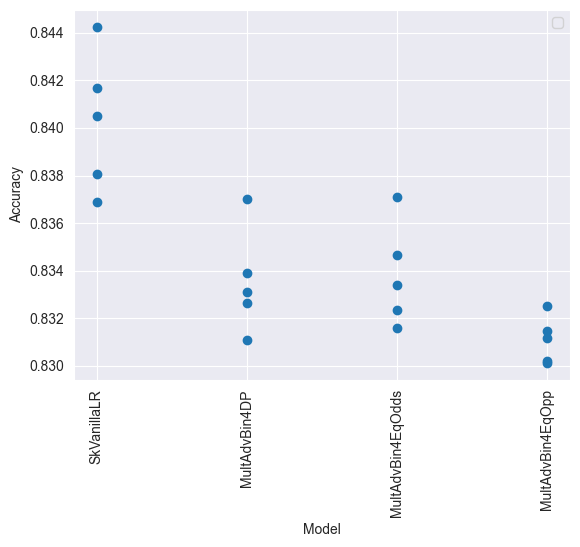

In [77]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [78]:
model_spd = vanilla['wc_spd'].to_list()+zhang['wc_spd'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25941/545090117.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


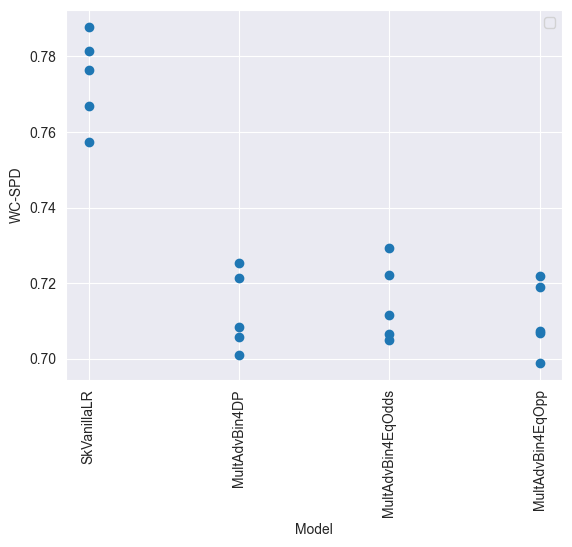

In [79]:
plt.plot()
plt.ylabel('WC-SPD')

plt.scatter(model_names, model_spd)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25941/1727290324.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


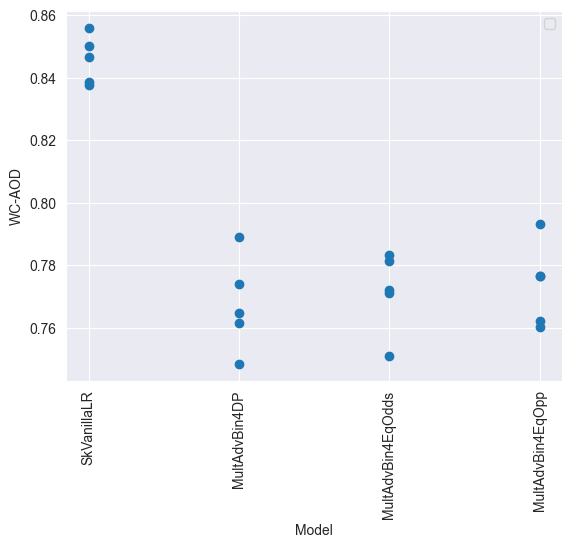

In [80]:
model_aod = vanilla['wc_aod'].to_list()+zhang['wc_aod'].to_list()
plt.plot()
plt.ylabel('WC-AOD')

plt.scatter(model_names, model_aod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_25941/2617305754.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


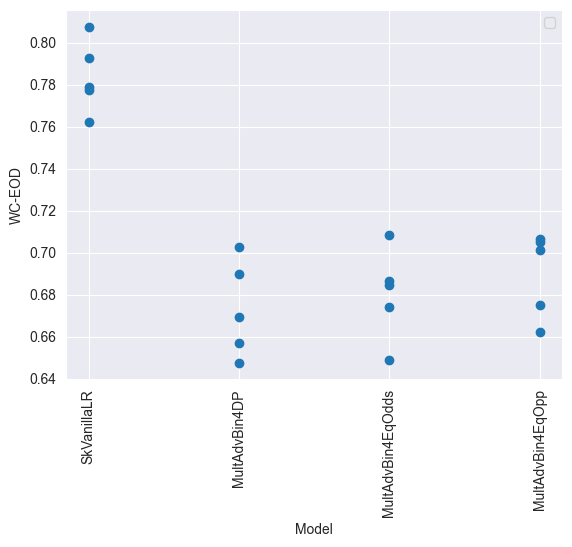

In [81]:
model_eod = vanilla['wc_eod'].to_list()+zhang['wc_eod'].to_list()
plt.plot()
plt.ylabel('WC-EOD')

plt.scatter(model_names, model_eod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x WC-SPD

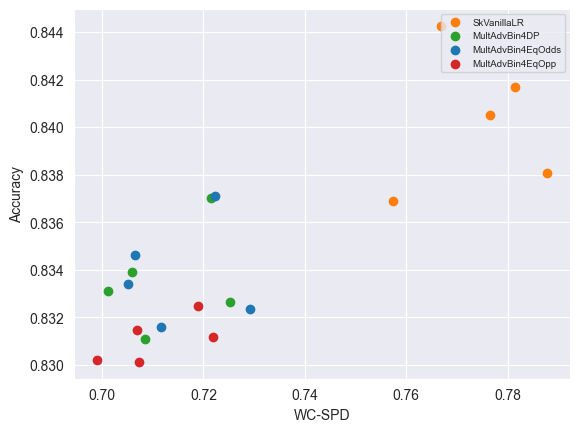

<Figure size 700x700 with 0 Axes>

In [82]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-SPD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_spd[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-AOD

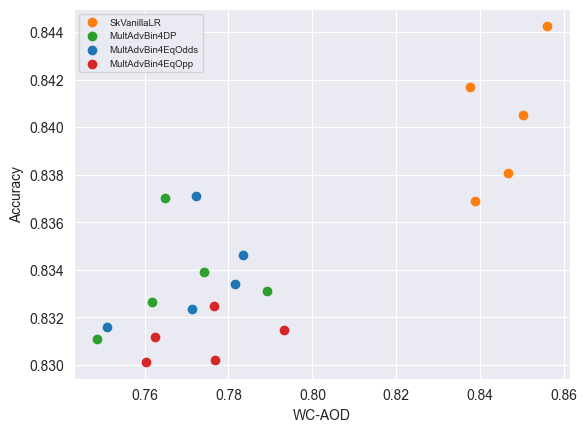

<Figure size 700x700 with 0 Axes>

In [83]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-AOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_aod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-EOD

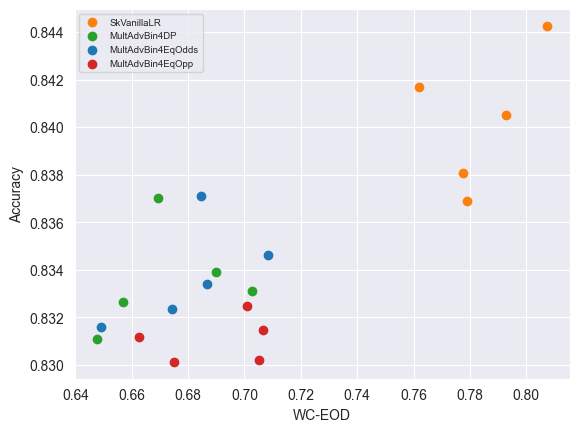

<Figure size 700x700 with 0 Axes>

In [84]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-EOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_eod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()